# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:*Muhammad Sufian*
**Student ID:*023-24-0007*
**Section:*B*
**GitHub:*https://www.kaggle.com/mohammadsufian3232*
**Kaggle:*https://github.com/msufianchoohan/ml-lab*
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


---

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

**Answer 1:**
_The Ames Housing dataset is used to predict SalePrice from house features, which helps buyers, sellers, agents, and appraisers estimate fair property values_

**Answer 2:**
_This is a regression problem because SalePrice is a continuous numeric value, so metrics like MAE, MSE, RMSE, and R² are used instead of classification metrics._

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [2]:
# Task 3 — load and inspect the dataset
train = pd.read_csv("train.csv")

print("Shape:", train.shape)
print()
train.info()
print()
print(train.head())
print()
print(train.describe())
print()
print("SalePrice summary:")
print(train["SalePrice"].describe())

Shape: (1460, 81)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  

**Observations:**
_(what did you notice about the data — size, ranges, any obvious oddities?)_

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: `SalePrice`

Numerical independent variables: `OverallQual`, `GrLivArea`, `GarageCars`, `TotalBsmtSF`, `FullBath`, `YearBuilt`, `LotArea`

Categorical independent variables: `Neighborhood`, `KitchenQual`, `ExterQual`, `CentralAir`

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [3]:
# Task 5 — define X and y, encode categorical columns
num_features = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF",
                 "FullBath", "YearBuilt", "LotArea"]
cat_features = ["Neighborhood", "KitchenQual", "ExterQual", "CentralAir"]
selected_features = num_features + cat_features

y = train["SalePrice"]
X_raw = train[selected_features].copy()

# CentralAir is binary (Y/N) -> map to 1/0
X_raw["CentralAir"] = X_raw["CentralAir"].map({"Y": 1, "N": 0})

# KitchenQual / ExterQual are ordered quality scales -> ordinal map
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
X_raw["KitchenQual"] = X_raw["KitchenQual"].map(quality_map)
X_raw["ExterQual"] = X_raw["ExterQual"].map(quality_map)

# Neighborhood is nominal (no inherent order) -> one-hot encode
X = pd.get_dummies(X_raw, columns=["Neighborhood"], drop_first=True)

print(X.shape)
X.head()

(1460, 34)


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,LotArea,KitchenQual,ExterQual,CentralAir,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,7,1710,2,856,2,2003,8450,4,4,1,...,False,False,False,False,False,False,False,False,False,False
1,6,1262,2,1262,2,1976,9600,3,3,1,...,False,False,False,False,False,False,False,False,False,True
2,7,1786,2,920,2,2001,11250,4,4,1,...,False,False,False,False,False,False,False,False,False,False
3,7,1717,3,756,1,1915,9550,4,3,1,...,False,False,False,False,False,False,False,False,False,False
4,8,2198,3,1145,2,2000,14260,4,4,1,...,True,False,False,False,False,False,False,False,False,False


In [4]:
# Task 7 — confirm X is fully numeric with no missing values
print("Unique dtypes in X:", X.dtypes.unique())
print("Total missing values in X:", X.isnull().sum().sum())
print("Total missing values in y:", y.isnull().sum())

Unique dtypes in X: [dtype('int64') dtype('bool')]
Total missing values in X: 0
Total missing values in y: 0


**Answer 6 (encoding justification):**
_CentralAir uses 1/0 because it is binary, KitchenQual and ExterQual use ordinal values (1–5) because they have a natural order, while Neighborhood uses one-hot encoding because it is nominal with no natural ranking_

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [5]:
# Task 8 — train/test split, report shapes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (1168, 34)
X_test:  (292, 34)
y_train: (1168,)
y_test:  (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [6]:
# Task 9 — train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#print("Model trained.")

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[12513.84, 44.21,11080.3 ,...,69329.08,27905.06,57486.52]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['OverallQual','GrLivArea','GarageCars',...,'Neighborhood_StoneBr', 'Neighborhood_Timber','Neighborhood_Veenker']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.274e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [7]:
# Task 10 — generate predictions, compare actual vs predicted
y_pred = lr_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
}).round(0).head(10)

comparison_df

,Actual Price,Predicted Price
0,154500,136218.0
1,325000,324358.0
2,115000,113024.0
3,159000,172570.0
4,315500,281516.0
5,75500,60245.0
6,311500,241402.0
7,146000,150334.0
8,84500,60080.0
9,135500,128003.0


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
| 154500 | 136218.0  |
| 325000 | 324358.0 |
| 115000 | 113024.0 |
| 159000 | 172570.0 |
| 315500 | 281516.0 |
| 75500 | 60245.0 |
| 311500 | 241402.0 |
| 146000 | 150334.0 |
| 84500 | 60080.0 |
| 135500 | 128003.0 |

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [8]:
# Task 11 — extract intercept and coefficients
intercept = lr_model.intercept_
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Intercept:", intercept)
print()
print(coef_table.to_string(index=False))

Intercept: -527380.5355554577

             Feature  Coefficient
Neighborhood_StoneBr 69329.076944
Neighborhood_NoRidge 68749.674715
Neighborhood_NridgHt 64582.292896
Neighborhood_Veenker 57486.520631
Neighborhood_Crawfor 46245.110262
Neighborhood_ClearCr 36586.902577
 Neighborhood_Timber 27905.064575
Neighborhood_BrkSide 25940.954938
Neighborhood_Somerst 25423.421082
Neighborhood_CollgCr 19338.246605
 Neighborhood_Sawyer 19065.662341
  Neighborhood_NAmes 17111.742906
 Neighborhood_IDOTRR 16951.201975
 Neighborhood_NWAmes 16602.210347
Neighborhood_Mitchel 15899.184493
  Neighborhood_SWISU 15868.258677
Neighborhood_Gilbert 15663.526458
         KitchenQual 13110.224347
Neighborhood_SawyerW 12832.348615
         OverallQual 12513.841758
          GarageCars 11080.295235
Neighborhood_NPkVill 10130.395771
Neighborhood_Edwards  9634.523497
          CentralAir  8070.567069
Neighborhood_MeadowV  7345.576552
Neighborhood_OldTown  7289.682419
           ExterQual  6976.728479
 Neighborhood_BrD

**Task 11 — Coefficient Table**

Intercept: **-527,380.54**

| Feature | Coefficient | Interpretation |
|---|---|---|
| OverallQual | 12,513.84 | Holding all else equal, each 1-point increase in overall material/finish quality (1-10 scale) adds about \$12,514 to predicted `SalePrice`. |
| GrLivArea | 44.21 | Holding all else equal, each additional square foot of above-ground living area adds about \$44 to predicted `SalePrice`. |
| GarageCars | 11,080.30 | Holding all else equal, each additional car of garage capacity adds about \$11,080 to predicted `SalePrice`. |
| TotalBsmtSF | 15.34 | Holding all else equal, each additional square foot of total basement area adds about \$15 to predicted `SalePrice`. |
| FullBath | -1,617.27 | Holding all else equal, each additional full bathroom is associated with a slight *decrease* of about \$1,617 — likely because bathroom count is correlated with (and partly redundant with) `GrLivArea` and `OverallQual`, which are already in the model. |
| YearBuilt | 215.57 | Holding all else equal, each later year the house was built in adds about \$216 to predicted `SalePrice`. |
| LotArea | 0.60 | Holding all else equal, each additional square foot of lot area adds about \$0.60 to predicted `SalePrice`. |
| KitchenQual | 13,110.22 | Holding all else equal, each 1-point increase on the 1-5 ordinal kitchen-quality scale adds about \$13,110 to predicted `SalePrice`. |
| ExterQual | 6,976.73 | Holding all else equal, each 1-point increase on the 1-5 ordinal exterior-quality scale adds about \$6,977 to predicted `SalePrice`. |
| CentralAir | 8,070.57 | Having central air (1) vs. not (0) adds about \$8,071 to predicted `SalePrice`, all else equal. |
| Neighborhood_* dummies | ranges from about -\$6,933 (BrDale) to +\$69,329 (StoneBr) | Each neighborhood dummy shows that neighborhood's price difference relative to the dropped baseline neighborhood, all else equal — `StoneBr`, `NoRidge`, and `NridgHt` command the largest premiums. |

*(Full per-neighborhood values are in the `coef_table` output above.)*

**Answer 12:**
The intercept (-\$527,380.54) represents the model's predicted `SalePrice` when every numeric feature is 0 and every categorical feature is at its reference/baseline level (e.g. `CentralAir`=0, quality scores=0, baseline neighborhood). That combination isn't realistic for an actual house (a house can't have 0 living area, 0 lot area, or have been "built in year 0"), and the negative value makes this even clearer — no real house would sell for a negative price. So the intercept here is mostly a mathematical anchor point for the regression line rather than a value with a sensible real-world interpretation on its own.

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

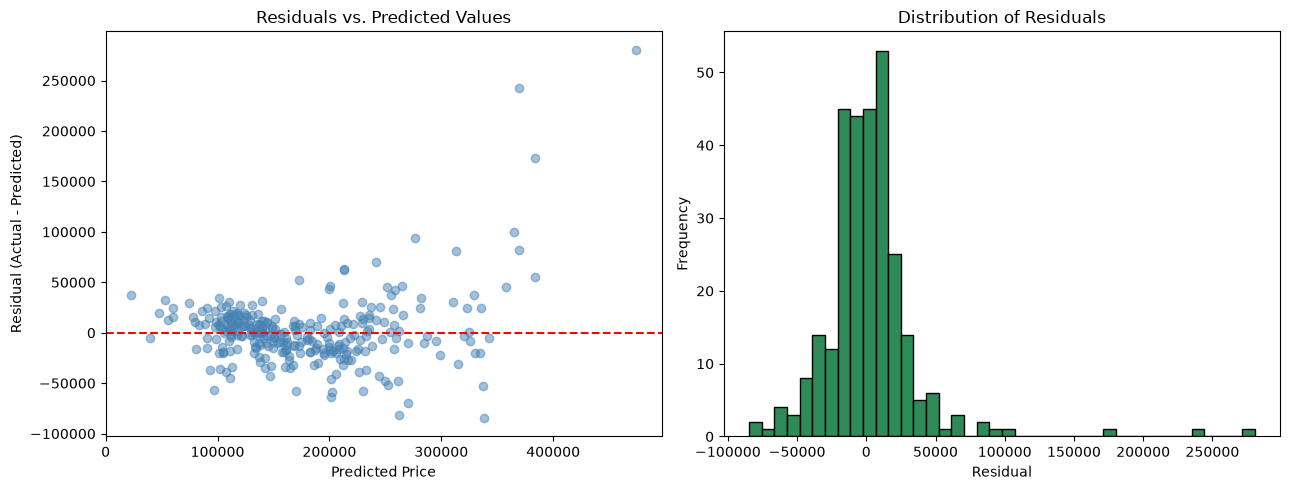

Residual mean: 1783.515167456569
Residual std: 35177.557822547446


In [13]:
# Task 13 — compute and plot residuals
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred, residuals, alpha=0.5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Price")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs. Predicted Values")

axes[1].hist(residuals, bins=40, color="seagreen", edgecolor="black")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

**Answer 13:**
_Residuals are mostly centered around zero, but their spread increases for higher prices, showing mild heteroscedasticity and that the model tends to underpredict expensive houses._

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [14]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae_test, mse_test, rmse_test, r2_test]
})
print(test_metrics.to_string(index=False))


Metric        Value
   MAE 2.116374e+04
   MSE 1.236404e+09
  RMSE 3.516253e+04
    R2 8.388069e-01


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE | 2.1163|
| MSE | 1.2364|
| RMSE | 3.5162|
| R² | 8.3880|

**Answer 15:**
_MAE ($21,164) shows the average error, RMSE ($35,163) gives more weight to large errors, and R² (0.839) means the model explains about 84% of price variation; RMSE is the best simple metric for stakeholders._

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [15]:
# Task 16 — compute training-set metrics
y_train_pred = lr_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

train_test_comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Training Set": [mae_train, mse_train, rmse_train, r2_train],
    "Test Set": [mae_test, mse_test, rmse_test, r2_test]
})
print(train_test_comparison.to_string(index=False))


Metric  Training Set     Test Set
   MAE  2.053380e+04 2.116374e+04
   MSE  1.095361e+09 1.236404e+09
  RMSE  3.309624e+04 3.516253e+04
    R2  8.163548e-01 8.388069e-01


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE | 2.053380e+04| 2.116374e+04|
| MSE | 1.095361e+09| 1.236404e+09|
| RMSE | 3.309624e+04| 3.309624e+04|
| R² | 8.163548e-01| 8.388069e-01|

**Answer 17:**
_Train and test results are very close, showing good generalization with little overfitting, but the $20k+ errors suggest some price variation is not captured by the selected features._

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
_OverallQual, GrLivArea, and Neighborhood have strong effects on price, but coefficient size alone is not enough because features use different scales; their impact should be compared using feature ranges or standardized values_

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
_The Linear Regression model predicts house prices reasonably well, with OverallQual and GrLivArea being the strongest features; however, it has limitations with non-linear relationships and missing features, so future improvements could include feature engineering, Ridge/Lasso, and tree-based models_

In [16]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
test_df = pd.read_csv("test.csv")

X_test_raw = test_df[num_features + cat_features].copy()

# Impute missing values the same way for numeric/categorical columns
# (test.csv has a few missing values that train.csv did not)
for col in num_features:
    if X_test_raw[col].isnull().any():
        X_test_raw[col] = X_test_raw[col].fillna(train[col].median())

for col in cat_features:
    if X_test_raw[col].isnull().any():
        X_test_raw[col] = X_test_raw[col].fillna(train[col].mode()[0])

# Apply the same encoding used on the training data
X_test_raw["CentralAir"] = X_test_raw["CentralAir"].map({"Y": 1, "N": 0})
X_test_raw["KitchenQual"] = X_test_raw["KitchenQual"].map(quality_map)
X_test_raw["ExterQual"] = X_test_raw["ExterQual"].map(quality_map)

X_kaggle_test = pd.get_dummies(X_test_raw, columns=["Neighborhood"], drop_first=True)

# Align columns with training X (adds any missing neighborhood dummy columns as 0,
# drops any that don't appear in test, and keeps the same column order)
X_kaggle_test = X_kaggle_test.reindex(columns=X.columns, fill_value=0)

print("Missing values remaining:", X_kaggle_test.isnull().sum().sum())

kaggle_predictions = lr_model.predict(X_kaggle_test)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": kaggle_predictions
})
submission.to_csv("submission.csv", index=False)

print(submission.shape)
submission.head()


Missing values remaining: 0
(1459, 2)


,Id,SalePrice
0,1461,112917.724802
1,1462,165476.897225
2,1463,163123.754156
3,1464,185524.187801
4,1465,258034.804932


**Answer 21 — Kaggle Leaderboard Result:**

Public score: _0.16905_

Rank: _561_

Reflection (1–2 sentences): _The public score of 0.16905 and rank of 561 show that the model performed reasonably well on the Kaggle leaderboard. This result helped me understand how model performance on unseen test data compares with my local validation results._

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted